# Instructions

For this project you will visualize time series data using a line chart, bar chart, and box plots. You will use Pandas, Matplotlib, and Seaborn to visualize a dataset containing the number of page views each day on the freeCodeCamp.org forum from 2016-05-09 to 2019-12-03. The data visualizations will help you understand the patterns in visits and identify yearly and monthly growth.

Use the data to complete the following tasks:

- Use Pandas to import the data from "fcc-forum-pageviews.csv". Set the index to the `date` column.
- Clean the data by filtering out days when the page views were in the top 2.5% of the dataset or bottom 2.5% of the dataset.
- Create a `draw_line_plot` function that uses Matplotlib to draw a line chart similar to "examples/Figure_1.png". The title should be `Daily freeCodeCamp Forum Page Views 5/2016-12/2019`. The label on the x axis should be `Date` and the label on the y axis should be `Page Views`.
- Create a `draw_bar_plot` function that draws a bar chart similar to "examples/Figure_2.png". It should show average daily page views for each month grouped by year. The legend should show month labels and have a title of `Months`. On the chart, the label on the x axis should be `Years` and the label on the y axis should be `Average Page Views`.
- Create a `draw_box_plot` function that uses Seaborn to draw two adjacent box plots similar to "examples/Figure_3.png". These box plots should show how the values are distributed within a given year or month and how it compares over time. The title of the first chart should be `Year-wise Box Plot (Trend)` and the title of the second chart should be `Month-wise Box Plot (Seasonality)`. Make sure the month labels on bottom start at `Jan` and the x and y axis are labeled correctly. The boilerplate includes commands to prepare the data.

For each chart, make sure to use a copy of the data frame.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

---
Import data (Make sure to parse dates. Consider setting index column to 'date'.)

In [2]:
df = pd.read_csv('fcc-forum-pageviews.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1304 non-null   object
 1   value   1304 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 20.5+ KB


In [3]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df

,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933
...,...
2019-11-29,171584
2019-11-30,141161
2019-12-01,142918


---
Clean data

In [4]:
lower = df['value'].quantile(0.025)  # Bottom 2.5%
upper = df['value'].quantile(0.975)  # Top 2.5%

df = df[(df['value'] >= lower) & (df['value'] <= upper)]
df

,value
date,
2016-05-19,19736
2016-05-26,18060
2016-05-27,19997
2016-05-28,19044
2016-05-29,20325
...,...
2019-11-24,138875
2019-11-29,171584
2019-11-30,141161


---
## Draw Line Plot

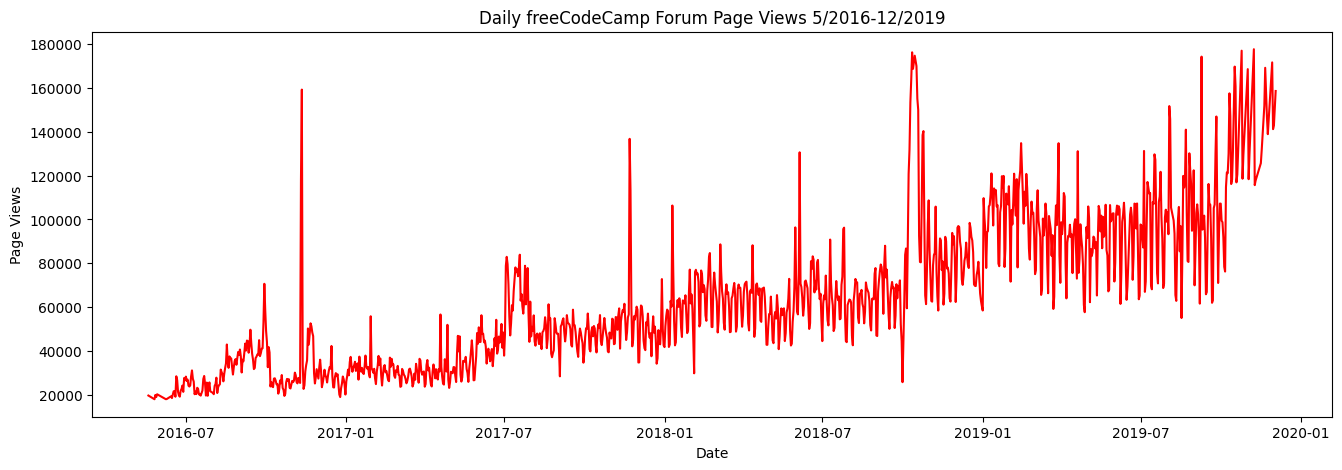

In [5]:
plt.figure(figsize=(16, 5))
plt.title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
plt.xlabel('Date')
plt.ylabel('Page Views')
plt.plot(df, 'r')

---
## Draw Bar Plot

In [6]:
df = df.copy()
df['year'] = df.index.year
df['month'] = df.index.month
df['month_name'] = df.index.month_name()
df

,value,year,month,month_name
date,,,,
2016-05-19,19736,2016,5,May
2016-05-26,18060,2016,5,May
2016-05-27,19997,2016,5,May
2016-05-28,19044,2016,5,May
2016-05-29,20325,2016,5,May
...,...,...,...,...
2019-11-24,138875,2019,11,November
2019-11-29,171584,2019,11,November
2019-11-30,141161,2019,11,November


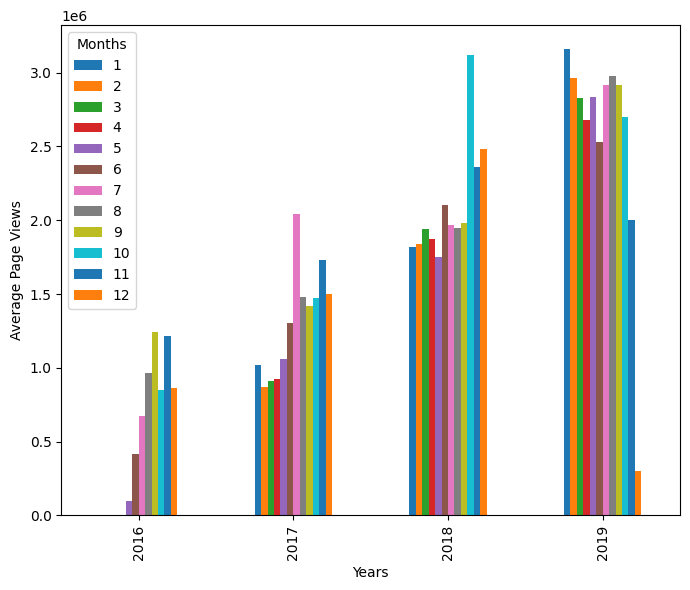

In [7]:
grouped = df.groupby(['year', 'month'])['value'].sum().unstack()

grouped.plot(kind='bar', figsize=(7, 6))
plt.xlabel('Years')
plt.ylabel('Average Page Views')
plt.legend(title='Months', loc='upper left', bbox_to_anchor=(0, 1))
plt.tight_layout()
plt.show()

---
## Draw Box Plot

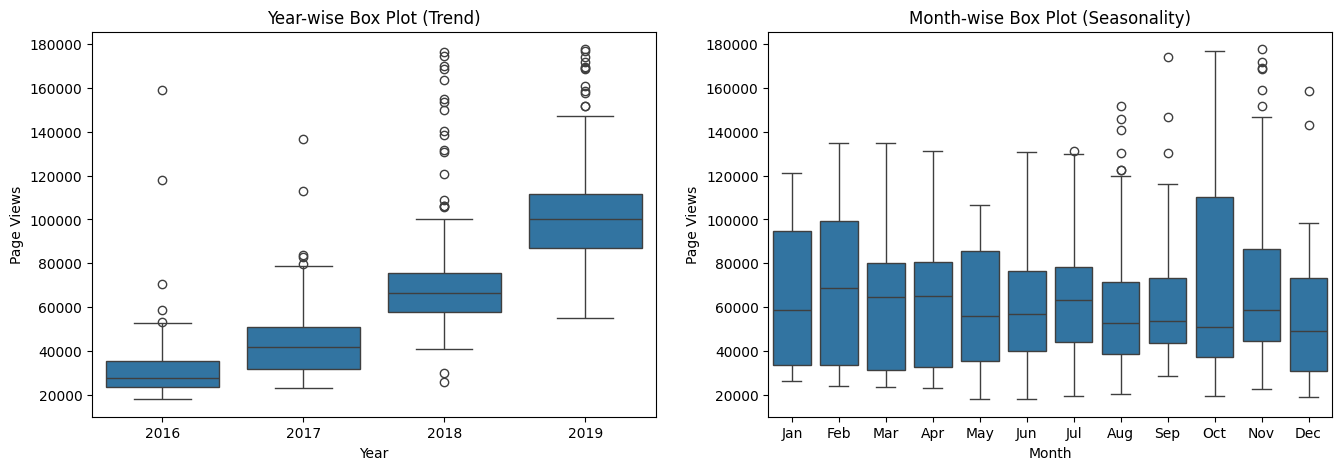

In [8]:
df_box = df.copy()
df_box.reset_index(inplace=True)
df_box['year'] = [d.year for d in df_box.date]
df_box['month'] = [d.strftime('%b') for d in df_box.date]
df_box['month_num'] = df_box['date'].dt.month
df_box = df_box.sort_values('month_num')

# Draw box plots (using Seaborn)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x='year', y='value', data=df_box, ax=ax[0])
ax[0].set_title('Year-wise Box Plot (Trend)')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Page Views')

sns.boxplot(x='month', y='value', data=df_box, ax=ax[1])
ax[1].set_title('Month-wise Box Plot (Seasonality)')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Page Views')

plt.show()